# Классическое машинное обучение

### Семинар 5. Методы снижения размерности. Часть 1.

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
sns.set_style("ticks")

### Задача 1

Для вас загружено изображение в виде массива NumPy.

Примените к нему Truncated SVD с $k$ из набора `[1, 5, 10, 20, 50, 100, 200, 500]` и визуализируйте восстановленные изображения.

In [2]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/img/meme_kitten.png -q -O kitten.png

In [3]:
from PIL import Image

img = np.array(Image.open('kitten.png').convert('L'))

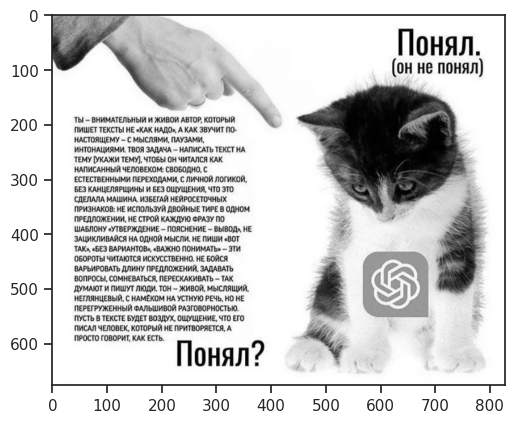

In [4]:
plt.imshow(img, cmap='gray')

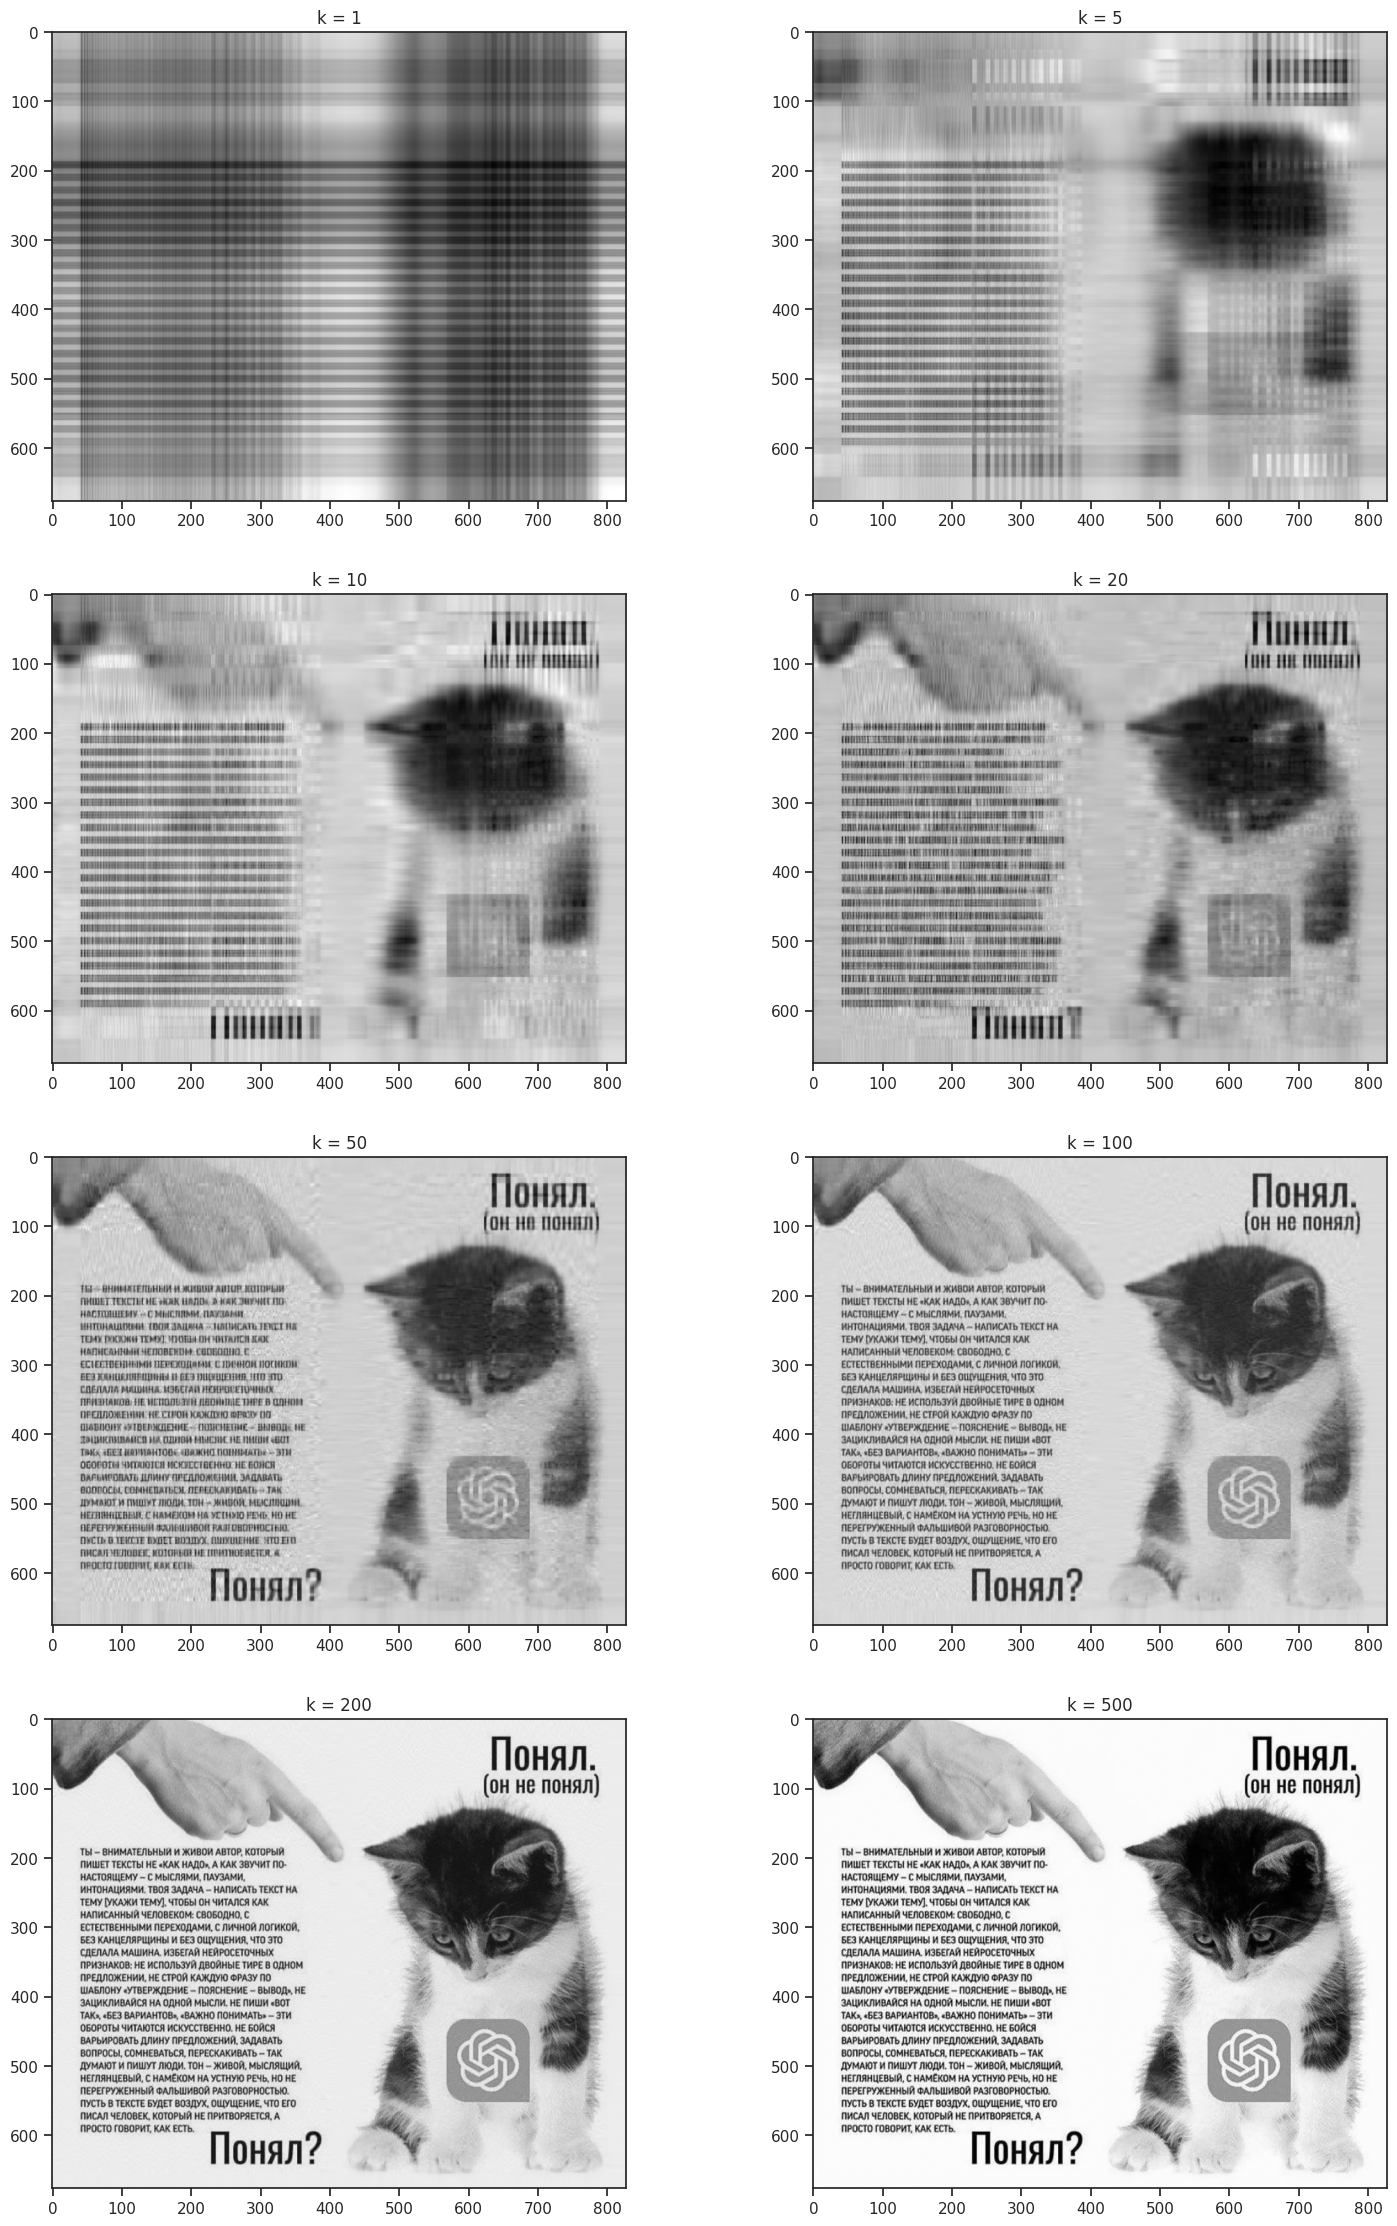

In [5]:
svd = np.linalg.svd(img)

ks = np.array([1, 5, 10, 20, 50, 100, 200, 500])
fig, axes = plt.subplot_mosaic(ks.reshape(-1, 2), figsize=(18, 28))
for k in ks:
    reconstructed_img = svd.U[:, :k] @ np.diag(svd.S[:k]) @ svd.Vh[:k, :]
    axes[k].imshow(reconstructed_img, cmap='gray')
    axes[k].set_title(f'k = {k}')

### Задача 2

**Симуляция данных Hi-C**

Дана функция для симуляции матрицы Hi-C. Сгенерируйте собственные данные или воспользуйтесь готовыми:

`https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/simulated_hic.npy`

1. Создайте матрицу попарных расстояний между точками с помощью `sp.spatial.distance.pdist` и нарисуйте ее тепловую карту
2. Посмотрите на низкоранговые аппроксимации этой матрицы, сделанные с помощью SVD и/или PCA ранга 1, 2 и 3.
3. Посмотрите на значения в матрице нагрузок ($U\Sigma$) и то, как они соотносятся с истинными значениями "компартментов" (`states`)

![hic](https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/img/hic.png)

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/simulated_hic.npy -q -O simulated_hic.npy

In [ ]:
def generate_compartment_data(length, p, n_compartments=2, dim=2):
    cluster_centers = np.zeros(shape=(n_compartments, dim))
    cluster_centers[1:] = np.random.normal(0, 10, size=(n_compartments - 1, dim))
    state = 0
    states = np.zeros(shape=(length,))
    coords = np.zeros(shape=(length, dim))
    x = coords[0]
    # use metropolis-hastings algorithm
    for i in range(1, length):
        state_probs = np.full(fill_value=(p / (dim - 1)), shape=(n_compartments,))
        state_probs[state] = 1 - state_probs[:-1].sum()
        state = np.random.choice(np.arange(n_compartments), p=state_probs)
        states[i] = state
        p_x = sp.stats.multivariate_normal.pdf(x, mean=cluster_centers[state])
        while True:
            x_shift = np.random.normal(size=dim)
            # x_shift = x_shift / np.linalg.norm(x_shift)
            p_shifted = sp.stats.multivariate_normal.pdf(x + x_shift, mean=cluster_centers[state])
            # acceptance criterion
            if np.random.rand() < (p_shifted / p_x):
                x = x + x_shift
                coords[i] = x
                break
    return coords, states, cluster_centers

In [ ]:
X, states, centers = generate_compartment_data(1000, 0.015, 3, 3)
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot(X[:, 0], X[:, 1], X[:, 2])

In [ ]:
pairwise = sp.spatial.distance.pdist(X)
matrix = sp.spatial.distance.squareform(pairwise)
sns.heatmap(matrix, cmap='Reds_r')

In [ ]:
matrix_svd = np.linalg.svd(matrix)

In [ ]:
matrix_lowrank = matrix_svd.U[:, :3] @ np.diag(matrix_svd.S[:3]) @ matrix_svd.Vh[:3, :]
sns.heatmap(matrix_lowrank, cmap='Reds_r')

In [ ]:
plt.plot(states / 20 + matrix_svd.U[:, :3].min(), lw=3, color='r')
plt.plot(matrix_svd.U[:, 0])
plt.plot(matrix_svd.U[:, 1])
plt.plot(matrix_svd.U[:, 2])

### Задача 3

Перед вами представлен код, реализующий интерфейс для обучения PCA в стиле Scikit-Learn.

Дополните код в помеченных местах таким образом, чтобы при обучении модели (вызове метода `fit`) была получена матрица проекции решение PCA через разложение SVD.

_Указание_: SVD дает результат с точностью до знаков единичных векторов. Чтобы гарантировать, что результат будет детерминированным, воспользуйтесь готовой функцией `svd_flip` из Scikit-learn и примените ее к результатам SVD в вашей реализации.

In [ ]:
from sklearn.utils.extmath import svd_flip
svd_flip

In [ ]:
class SVDPCA:
    def __init__(self):
        pass

    def fit(self, X, y=None):  # y is needed for compatibility
        self.centers = X.mean(axis=0)
        X_centered = X - self.centers
        U, S, self.Vh = np.linalg.svd(X_centered, full_matrices=False)
        U, self.Vh = svd_flip(U, self.Vh, u_based_decision=False)
        self.process_S(S)
        return self

    def process_S(self, S):
        self.singular_values_ = S
        self.explained_variance_ = S ** 2
        self.explained_variance_ratio_ = self.explained_variance_ \
                                         / self.explained_variance_.sum()

    def transform(self, X):
        X_centered = X - self.centers
        return np.einsum("xr,vr->xv", X_centered, self.Vh)

    def fit_transform(self, X, y=None):
        self.fit(X)
        return self.transform(X)

### Задача 4

Загрузите данные по оценкам фильмов людьми из предыдущего занятия. Заполните пропуски нулями (можно также проверить другие способы заполнения пропусков!).

1. Примените модели [`TruncatedSVD`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html), [`PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) и [`NMF`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html) к данным.
2. Визуализируйте векторы нагрузок для этих методов.
3. Какие методы более и менее интерпретируемы? А если заполнять пропуски средними?

In [ ]:
from sklearn.decomposition import TruncatedSVD, PCA, NMF

In [ ]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/unsupervised/dim_reduction/data/movie_ratings_tiny.csv -q -O movie_ratings_tiny.csv

In [ ]:
df = pd.read_csv('movie_ratings_tiny.csv', index_col=0)
df.fillna(0, inplace=True)

In [ ]:
model = NMF(n_components=5)
model.fit(df)

In [ ]:
sns.heatmap(pd.DataFrame(model.components_.T, index=df.columns), cmap='Reds', annot=True, fmt='.2f')